## **Data-Driven Medical Claim Repricing Framework**
### **Project Objective**
In line with the Ministry of Health (MOH) and Bank Negara Malaysia (BNM) White Paper on the Base MHIT Plan (RESET Strategy), this analysis aims to identify the trends in medical claims of dataset commencing from 2023 to 2025. Our Objective is to develop a robust repricing framework that promotes equity, identifies cost-control opportunities, and ensures financial sustainability for insurers.

### **Notebook Content**
1. Data Cleaning and Validation
    - Addressing data inconsistencies (missing vakues, neagative length of stay) to ensure high-fidelity inputs.
2. Exploratory Data Analysis (EDA)
    - Visualizing claim distributions to identify medical inflation and cost drivers.
3. Risk-Severity Analytics
    - Utilizing clustering and predictive modeling to tier hospitals based on risk-adjusted costs.
    - Separated into three parts: 
        * Part A: Clustering Analysis for DRG-Related Grouping
        * Part B: Total Claim Cost Prediction Model
        * Part C: Hospital Tiering 

#### **Data Cleaning and Validation**
To ensure the validity of our subsequent analysis, we perform rigorous audit to the raw claim records. As actuarial data requires high precision, thus, the following problems are addressed in this part:
1. Anomaly Correction
    - Rectifying logical errors (e.g., negative values in `length_of_stay`) to ensure chronological consistency in patient records.
2. Missing Value Replacement
    - Replace the missing values in the dataset by inferring to the assumptions and logic stated below:
        * Categorical Inference
            - We address missing `major_category` values by referencing the relationship between `sub_category` and the `procedure_diagnosis`.
        * Financial Accounting Identity
            - Medical claims fllow an accounting identity: `Total Claim = Doctor + Hospital + Medical + Investigation`. In this case, when the `investigation_cost` is missing, it can be inferred by calculating the residue of the bill.
        * Enforcing Policy Rules
            - As stated in the MHIT White Paper, `patient_co_payment` is not a random variable, as it is a contractual policy condition, where we enforce the 20% co-payment rule, and ensure that it does not exceed the RM3000 policy cap.
        * Reconstrcuting Patients' Journey
            - The missing values are calculated using arithmetic consistency. `length_of_stay` is calculated via `rb_entitlement_total`, and `discharge_date` is projected from the admission timestamp.
3.  Residual Data Observations and Scope Constraints
    - Categorical Nuance: Hybrid healthcare Providers (FPP)
        * We idenfied a hsopital in Negeri Sembilan (Hospital Negeri Sembilan) exibits characteristics of both public and private sector billing. Rather than forcing a binary classification, we have recognised this as a Full Paying Patient (FPP) hybrid facility. This distiction is crucial to prevent the misclassification of FPP-specific pricing as "inefficient" private claims, ensuring our risk-severity matrix remains robust. 
    - Inherent Outlier Validity
        * We observed extreme values in columns such as `total_claim_amount` that, while statistically anomalous, represent valid occurrences in healthcare financing. Removing these would risk underestimating the financial risk profile, so they have been preserved for the clustering model to identify as potential "Tier 2" outliers.
    



In [1]:
# import necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from matplotlib.ticker import FuncFormatter
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
# Read the dataset
df = pd.read_csv("UMACT_HACKATHON_2026_FINALVERSION.csv")

In [3]:
# Get insights from the dataset
df.head(5)

,claim_id,policyholder_id,patient_age,patient_gender,smoker_status,bmi,chronic_conditions,has_previous_claims,plan_type,room_and_board_limit,...,procedure_diagnosis,doctor_fees,hospital_charges,medication_cost,investigation_cost,total_claim_amount,rb_entitlement_total,patient_co_payment,insurance_paid,hits_cap
0,MHC0000001,PH02843,4,F,Non-Smoker,27.1,0,0,Gold,350,...,Dengue Haemorrhagic Fever,1555.25,3393.28,1272.48,848.32,7069.33,1750,1413.87,5655.46,False
1,MHC0000002,PH07593,33,M,Non-Smoker,15.2,0,0,Basic,150,...,Asthma Exacerbation,6179.34,13482.19,5055.82,3370.55,28087.90,750,3000.00,25087.90,True
2,MHC0000003,PH00983,1,M,Non-Smoker,27.6,0,0,Basic,150,...,Asthma Exacerbation,6789.39,14813.21,5554.95,3703.30,30860.85,900,3000.00,27860.85,True
3,MHC0000004,PH03707,33,F,Non-Smoker,30.2,0,0,Silver,250,...,Normal Delivery,6137.88,13391.75,5021.90,3347.94,27899.47,750,3000.00,24899.47,True
4,MHC0000005,PH05756,17,M,Non-Smoker,30.4,0,0,Gold,350,...,Dengue Haemorrhagic Fever,1379.66,3010.17,1128.81,752.54,6271.18,1400,1254.24,5016.94,False


In [4]:
# Basic info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   claim_id              20000 non-null  object 
 1   policyholder_id       20000 non-null  object 
 2   patient_age           20000 non-null  int64  
 3   patient_gender        20000 non-null  object 
 4   smoker_status         20000 non-null  object 
 5   bmi                   20000 non-null  float64
 6   chronic_conditions    20000 non-null  int64  
 7   has_previous_claims   20000 non-null  int64  
 8   plan_type             20000 non-null  object 
 9   room_and_board_limit  20000 non-null  int64  
 10  patient_state         20000 non-null  object 
 11  region                20000 non-null  object 
 12  hospital_name         20000 non-null  object 
 13  hospital_type         20000 non-null  object 
 14  admission_type        20000 non-null  object 
 15  admission_date     

In [5]:
# Get insight of central tendency and statistical value
df.describe()

,patient_age,bmi,chronic_conditions,has_previous_claims,room_and_board_limit,length_of_stay,doctor_fees,hospital_charges,medication_cost,investigation_cost,total_claim_amount,rb_entitlement_total,patient_co_payment,insurance_paid
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,19700.000000,20000.000000,20000.000000,20000.000000,19560.000000,20000.000000,20000.00000,19400.000000,20000.000000
mean,41.810350,27.094455,1.010650,0.568250,259.240000,5.289391,12932.382046,28216.106208,10581.039794,7046.988376,58783.554600,1379.04000,2765.943685,56018.296644
std,24.526397,6.176665,1.129469,0.495332,121.038651,2.096330,12629.930747,27556.212625,10333.579744,6888.599356,57408.776245,876.63225,535.185731,57202.072675
min,0.000000,12.000000,0.000000,0.000000,150.000000,-10.000000,905.870000,1976.430000,741.160000,494.110000,4117.570000,150.00000,823.510000,3294.060000
25%,20.000000,23.200000,0.000000,0.000000,150.000000,4.000000,4730.850000,10321.865000,3870.695000,2575.740000,21503.877500,750.00000,3000.000000,18503.877500
50%,42.000000,26.700000,1.000000,1.000000,250.000000,5.000000,7109.970000,15512.655000,5817.245000,3875.010000,32318.035000,1200.00000,3000.000000,29318.035000
75%,63.000000,30.500000,2.000000,1.000000,350.000000,7.000000,19652.085000,42877.285000,16078.982500,10702.247500,89327.670000,1750.00000,3000.000000,86327.670000
max,84.000000,65.000000,4.000000,1.000000,550.000000,14.000000,55000.000000,120000.000000,45000.000000,30000.000000,250000.000000,6600.00000,3000.000000,247000.000000


In [6]:
# Check the number of each missing value in each column
df.isna().sum()

claim_id                  0
policyholder_id           0
patient_age               0
patient_gender            0
smoker_status             0
bmi                       0
chronic_conditions        0
has_previous_claims       0
plan_type                 0
room_and_board_limit      0
patient_state             0
region                    0
hospital_name             0
hospital_type             0
admission_type            0
admission_date            0
discharge_date          300
length_of_stay          300
major_category          700
sub_category              0
procedure_diagnosis       0
doctor_fees               0
hospital_charges          0
medication_cost           0
investigation_cost      440
total_claim_amount        0
rb_entitlement_total      0
patient_co_payment      600
insurance_paid            0
hits_cap                  0
dtype: int64

In [7]:
# Check whether there are any duplicated row in the dataset
df.duplicated().sum()

np.int64(0)

In [8]:
# Filling in null values for major_category by inferring the values of sub_category and procedure_diagnosis
mapping = (
    df[df['major_category'].notna()]
    .groupby(['sub_category', 'procedure_diagnosis'])['major_category']
    .agg(lambda x: x.mode()[0])  # most frequent value
)

def fill_major(row):
    if pd.isna(row['major_category']):
        key = (row['sub_category'], row['procedure_diagnosis'])
        return mapping.get(key, np.nan)
    return row['major_category']

df['major_category'] = df.apply(fill_major, axis=1)

# Filling in null values in the investigation_cost by applying the formula investigation_cost = total_claim_amount - doctor_fees - hospital_charges - medication_cost
df['investigation_cost'] = df['investigation_cost'].fillna(
    df['total_claim_amount']
    - df['doctor_fees']
    - df['hospital_charges']
    - df['medication_cost']
)

# Filling in null values in the patient_co_payment by applying the formula, patient_co_payment = total_claim_amount * 0.2, capped at RM3000
df['patient_co_payment'] = df['patient_co_payment'].fillna(
    df['total_claim_amount'] * 0.2).clip(upper=3000)

# Filling in null values in the length_of_stay by referring the formula, length_of_stay = rb_entitlement_total/room_and_board_limit
df['length_of_stay'] = df['length_of_stay'].fillna(
    df['rb_entitlement_total'] / df['room_and_board_limit']
)

# Filling in the null values in the discharge_date by referring the formula, discharge_date = admission_date + length_of_stay
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

df.loc[df['discharge_date'].isna(), 'discharge_date'] = (
    df['admission_date'] + pd.to_timedelta(df['length_of_stay'], unit='D')
)

df.isna().sum()

claim_id                0
policyholder_id         0
patient_age             0
patient_gender          0
smoker_status           0
bmi                     0
chronic_conditions      0
has_previous_claims     0
plan_type               0
room_and_board_limit    0
patient_state           0
region                  0
hospital_name           0
hospital_type           0
admission_type          0
admission_date          0
discharge_date          0
length_of_stay          0
major_category          0
sub_category            0
procedure_diagnosis     0
doctor_fees             0
hospital_charges        0
medication_cost         0
investigation_cost      0
total_claim_amount      0
rb_entitlement_total    0
patient_co_payment      0
insurance_paid          0
hits_cap                0
dtype: int64

In [9]:
# From the dataset, if the length_of_stay is negative, switch the value of admission_date and discharge_date and change the negative value to positive
mask = df['length_of_stay'] < 0

df.loc[mask, ['admission_date', 'discharge_date']] = df.loc[mask, ['discharge_date', 'admission_date']].values

df.loc[mask, 'length_of_stay'] = df.loc[mask, 'length_of_stay'].abs()

### **Exploratory Data Analysis (EDA)**
To align with the Base MHIT Plan (RESET Strategy), we would like to focus on the insights that the dataset provided to us. In this section, we tests our hypotheses regarding the medical claim inflation and hospital billing efficiency.
1. Drivers of Medical Inflation
    - Medical inflation is driven primarily by excessive `investigation_cost` and `hospital_charges` rather than the `length_of_stay`.
    - We conduct a correlation analysis (Heatmap) to identify which variables have the highest impact on `total_claim_amount`.
    - If the `investigation_cost` shows the strongest correlation, our repricing recommendation will need to prioritize transparent diagnostics pricing rather than access to care.
2. Risk-Severity Segmentation
    - Claim distribution is not uniform, and thus there is a significant "long-tail" of high-severity claims that necessitates a two-tier hospital classification.
    - We visualize the distribution of `total_claim_amount` using boxplots and calculate the outlier percentile by the formula `Q3 + 1.5 * IQR`.
    - A skewed distribution (high number of outliers) justifies our K-Means clustering model, where a "one-size-fits-all" pricing policy is inequitable, supporting the need of Tier 1 (Standard) and Tier 2 (High-Risk/ Outliers) hospital classifications.
3. Regional Benchmarking
    - Medical inflation is not unifrom across the nation, there is significant geographic variance in claim costs due to variations in facility density, cost-of-living, and local service delivery models.
    - We performed a comparative analysis of average claim costs aggregated by `region` and `hospital_type`. This allows us to move beyond a "one-size-fits-all" national pricing model and evaluate healthcare financing through a regionally adjusted lens.
    - The visualisation demonstrates clear disparities in average costs across regions. In most of the regions, private facilities significantly outpace public facilities, but we need to take in consideration of FPP (Full Paying Patient) as well.

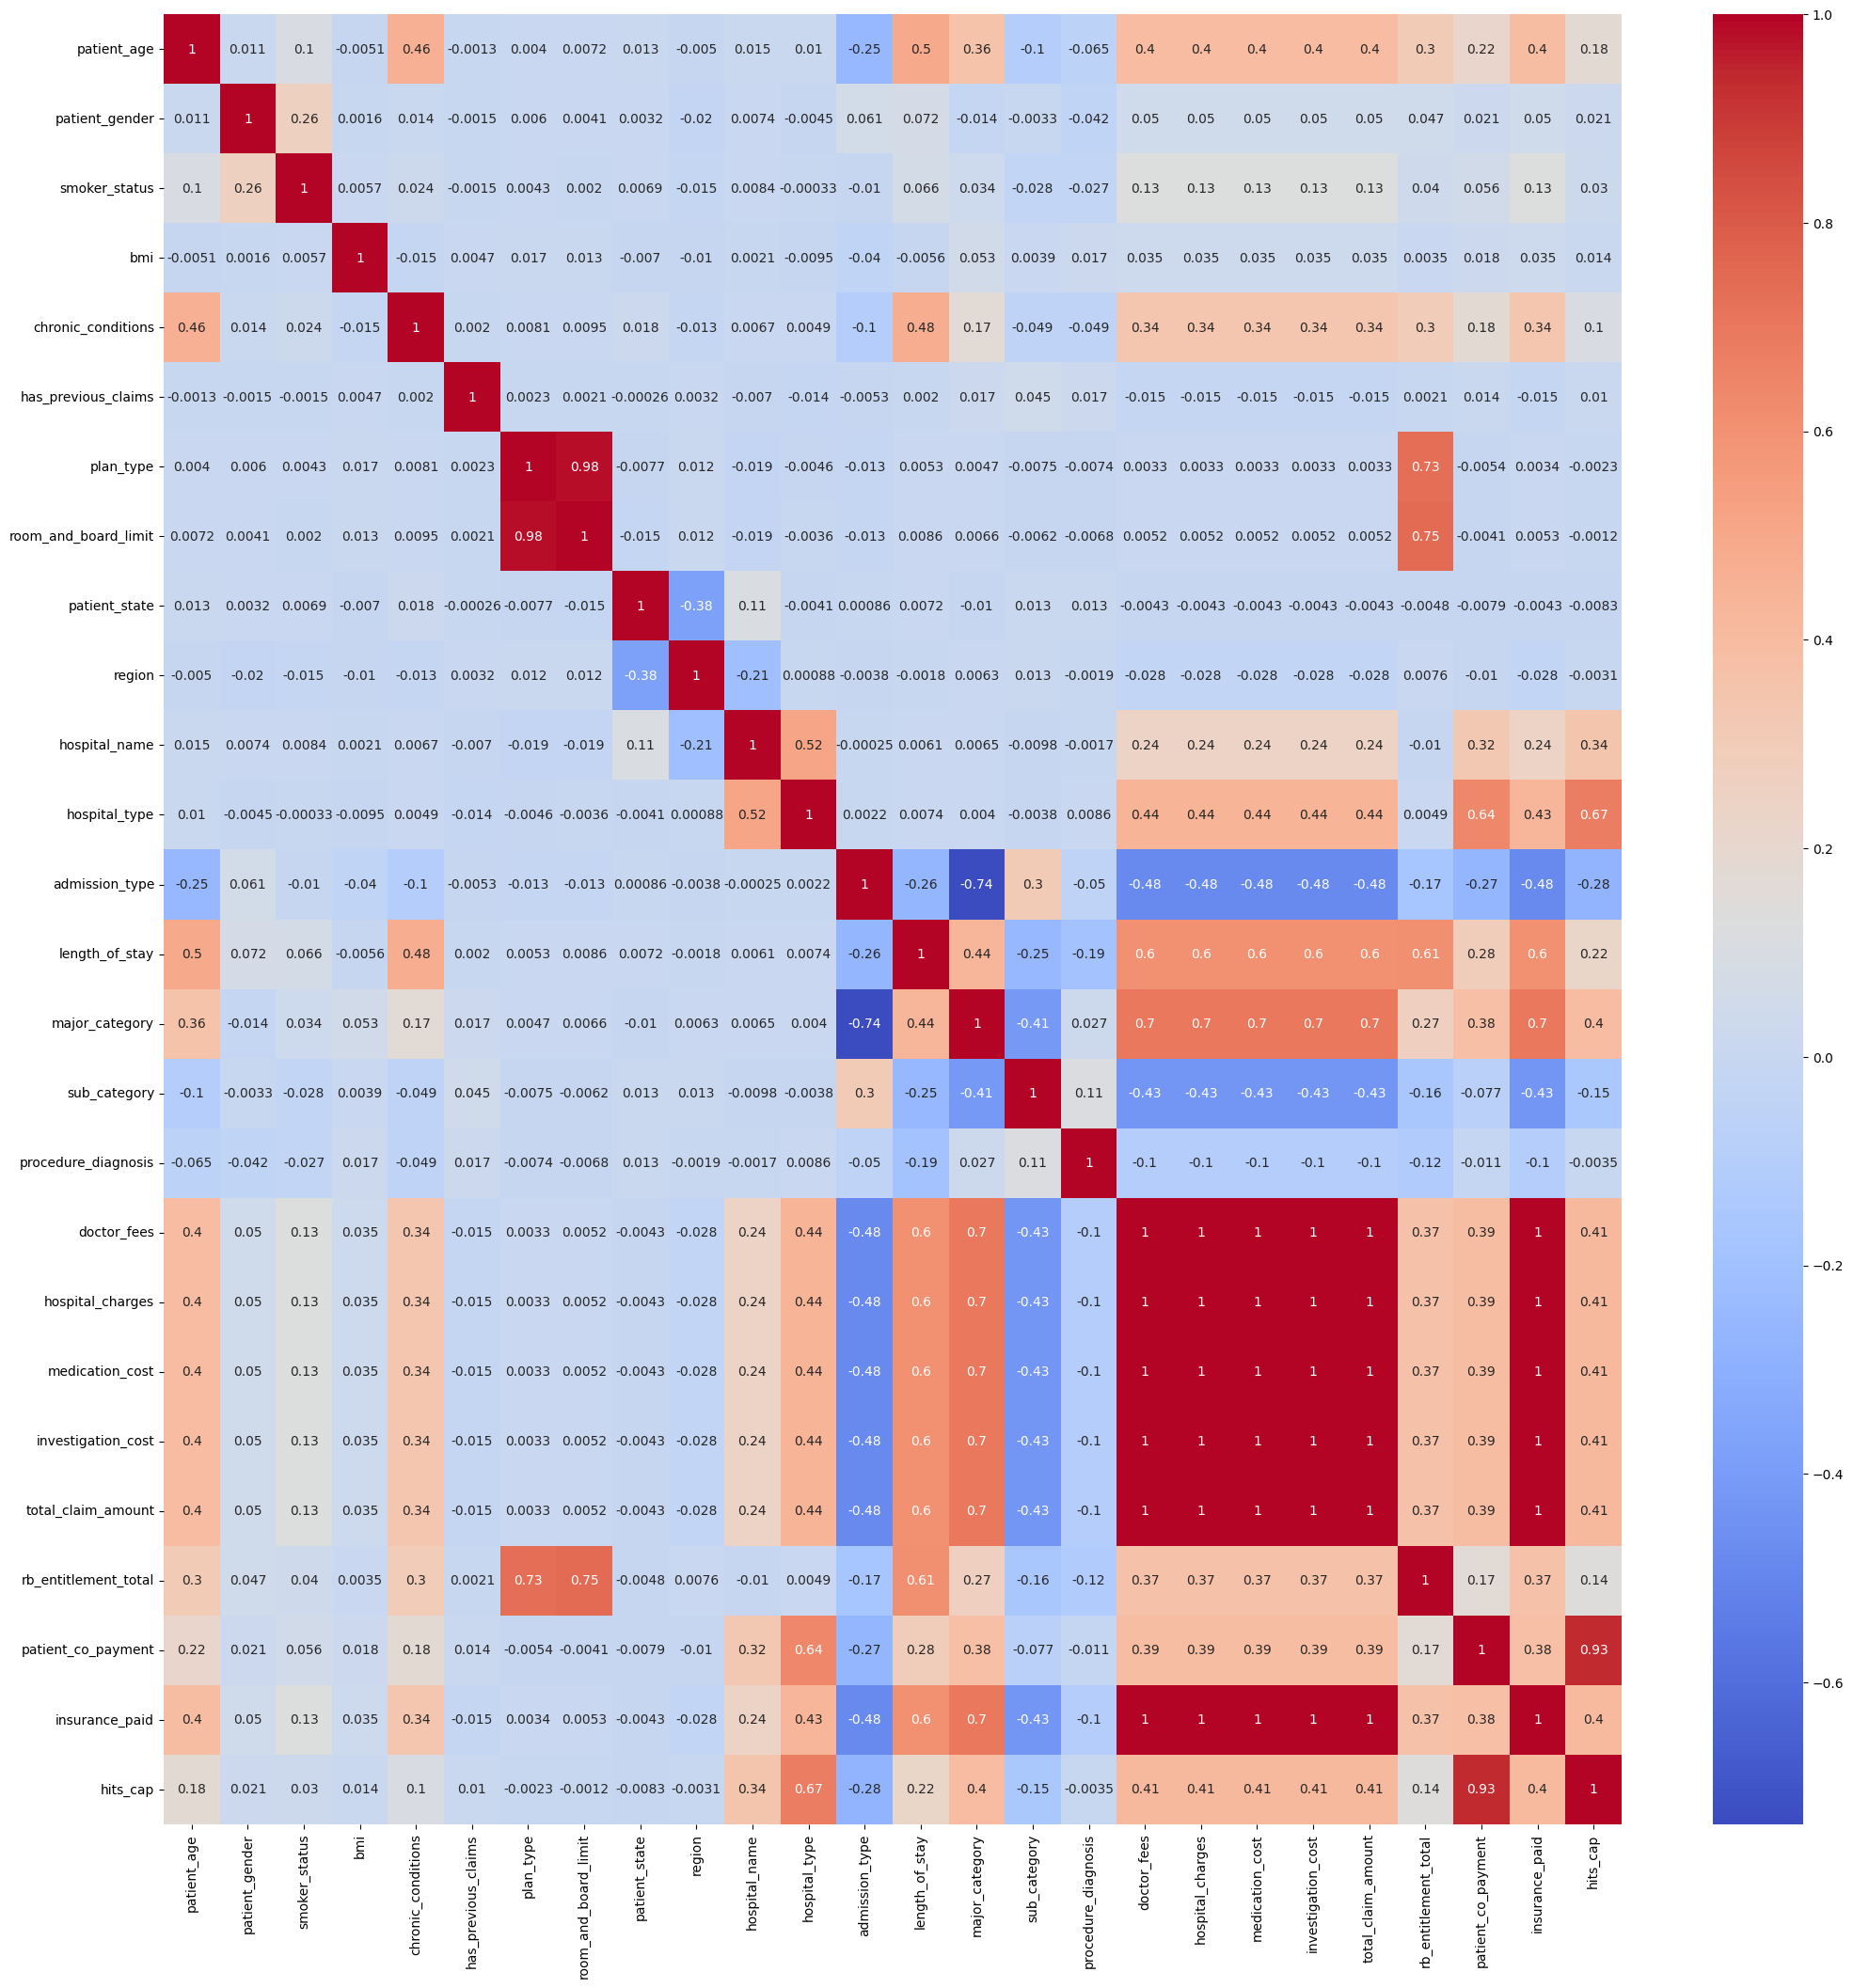

In [10]:
# Correlation matrix

# Create a copy
df_processed = df.copy()

# Drop IDs
df_processed = df_processed.drop(['claim_id', 'policyholder_id'], axis=1)

# Convert boolean
df_processed['hits_cap'] = df_processed['hits_cap'].astype(int)

# Encode categorical value to numerical value
df_processed['patient_gender'] = df_processed['patient_gender'].map({
    'M': 1,
    'F': 0
})

df_processed['smoker_status'] = df_processed['smoker_status'].map({
    'Smoker': 1,
    'Non-Smoker': 0
})

df_processed['plan_type'] = df_processed['plan_type'].map({
    'Basic': 0,
    'Silver': 1,
    'Gold': 2,
    'Platinum': 3
})

label_encoders = {} 

cols = [
    'patient_state',
    'region',
    'hospital_name',
    'hospital_type',
    'admission_type',
    'major_category',
    'sub_category',
    'procedure_diagnosis'
]

# Make a list to map the categorical values with the mapped values for future reference purpose
for col in cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    
    label_encoders[col] = le

# Drop date columns (As the information is already been used for calculate the Length of Stay)
df_processed = df_processed.drop(['admission_date', 'discharge_date'], axis=1)

# Plot the Correlation heatmap
plt.figure(figsize=(25,25))
sns.heatmap(df_processed.corr(), annot = True, cmap='coolwarm')
plt.show()

The strong correlations among cost-related variables indicate multicollinearity, as these features capture overlapping information about total medical expenses. As each costs holds the same ratio in the `total_claim_amount`, all the type of costs are equally important. This suggests redundancy in the dataset, where multiple variables represent different components of the same underlying cost structure.

In [11]:
# Print the mappings for reference purposes
all_mappings = []

for col, le in label_encoders.items():
    encoded_values = le.transform(le.classes_).astype(int)
    
    df_temp = pd.DataFrame({
        'Column': col,
        'Label': le.classes_,
        'Encoded_Value': encoded_values
    })
    all_mappings.append(df_temp)

final_df = pd.concat(all_mappings, ignore_index=True)

final_df.head(10)

,Column,Label,Encoded_Value
0,patient_state,Johor,0
1,patient_state,Kedah,1
2,patient_state,Kelantan,2
3,patient_state,Kuala Lumpur,3
4,patient_state,Labuan,4
5,patient_state,Melaka,5
6,patient_state,Negeri Sembilan,6
7,patient_state,Pahang,7
8,patient_state,Penang,8
9,patient_state,Perak,9


In [12]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_d")
def comma_format(x, pos):
    return f'{x:,.0f}'
formatter = FuncFormatter(comma_format)

In [13]:
# Group the patients according to age group
bins = [0, 17, 35, 50, 65, float('inf')]
labels = ["Child (0-17)", "Young Adult (18-35)", "Middle Age (36-50)", "Senior (51-65)", "Elderly (66+)"]

df['age_group'] = pd.cut(
    df['patient_age'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True)

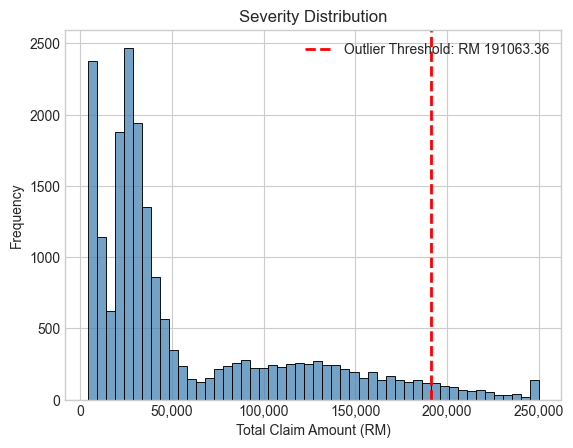

In [14]:
# Claim severity distribution
# Calculate the outlier threshold using the IQR method
Q1 = df['total_claim_amount'].quantile(0.25)
Q3 = df['total_claim_amount'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR

# Histogram with the outlier threshold
sns.histplot(df['total_claim_amount'], bins=50, color='steelblue', kde=False) 
plt.axvline(outlier_threshold, color='red', linestyle='--', linewidth=2, label=f'Outlier Threshold: RM {outlier_threshold:.2f}')
plt.gca().xaxis.set_major_formatter(formatter) 
plt.title("Severity Distribution")
plt.xlabel("Total Claim Amount (RM)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

A strong right-skewed distribution of claim severity indicates that the majority of claims are concentrated at lower cost levels. However, a small number of high-cost cases may be driven by differences in treatment complexity, hospital type and underlying patient conditions. The significant variance in medical costs highlights that risk-based pricing and customer segmentation are necessary to develop cost-controlled policies for financial sustainability and affordability.

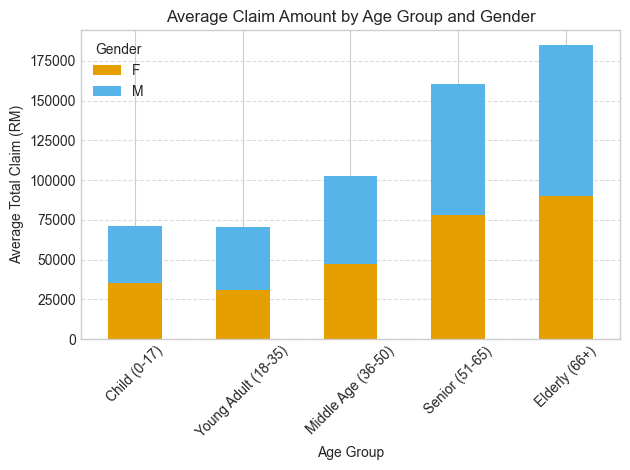

In [15]:
# Demographic Trends
# Group data by age group and gender, then convert to wide format for plotting
demo_summary = df.groupby(['age_group', 'patient_gender'], observed=False)['total_claim_amount'].mean().unstack()

# Stacked bar chart for average claim amount
demo_summary.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#E69F00', '#56B4E9'])
plt.title("Average Claim Amount by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Average Total Claim (RM)")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The total gross medical bill increase significantly with age, with noticeable spike that is at least 2 times higher than young-adult group for senior and elderly patients. Males show slightly higher claim frequency than females across all age groups, but the difference is negligible compared to the impact of age. This suggests that gender-based premium adjustments would yield marginal gains in risk accuracy compared to age-based tiering system. 

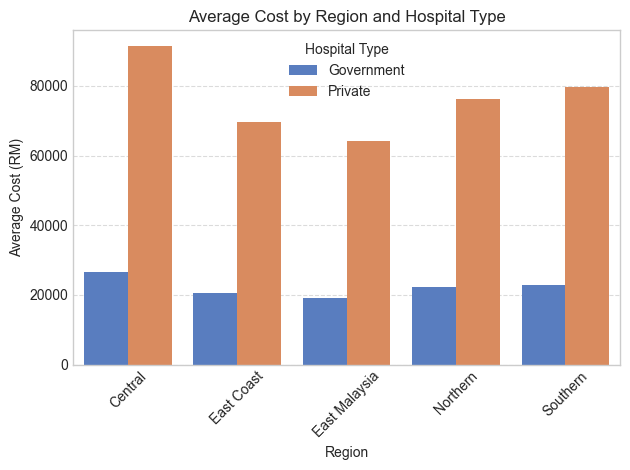

In [16]:
# Regional benchmark
# Group data by region and hospital type
regional_summary = df.groupby(['region', 'hospital_type'], observed=False).agg(
    avg_cost=('total_claim_amount', 'mean'),
    count=('total_claim_amount', 'size')).reset_index()

# Bar plot
sns.barplot(
    data=regional_summary, 
    x='region', 
    y='avg_cost', 
    hue='hospital_type',
    palette="muted")

plt.title("Average Cost by Region and Hospital Type")
plt.xlabel("Region")
plt.ylabel("Average Cost (RM)")
plt.xticks(rotation=45)
plt.legend(title="Hospital Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The regional analysis shows that private hospitals in Malaysia are significantly more costly than government facilities, likely driven by private-sector pricing models. The Central region recorded the highest costs that reflect increasing medical inflation caused by high demand and usage of advanced medical technology, while East Malaysia shows the lowest cost, that may due to limited accessibility and lower demand of specialized medical services in those states. 

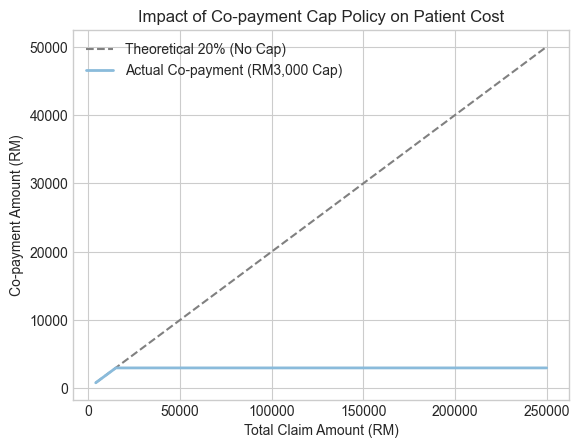

In [17]:
# Co-payment Cap Policy Impact
# Theoretical co-payment without cap
sns.lineplot(x='total_claim_amount', y=df['total_claim_amount'] * 0.2, data=df,
             label='Theoretical 20% (No Cap)', linestyle='--', color='gray')

# Actual co-payment with policy cap 
sns.lineplot(x='total_claim_amount', y=df['patient_co_payment'], data=df, 
             label='Actual Co-payment (RM3,000 Cap)', linewidth=2)

plt.title("Impact of Co-payment Cap Policy on Patient Cost")
plt.xlabel("Total Claim Amount (RM)")
plt.ylabel("Co-payment Amount (RM)")
plt.legend()
plt.show()

This policy does not designed for minor treatments that are affordable. The RM3000 co-payment cap significantly reduces financial burden for high-cost patients that claims exceed RM15000 threshold; however it may be costly for insurers if the policy does not accompanied by standardized cost-control measures, leading to risk of over-utilization of healthcare services. 

## **Risk-Severity Analysis**
In alignment with the Base MHIT Plan (RESET Strategy), our objective is to move away from aggregate billing toward a Value-Based Reimbursement framework. This section implements a three-stage analytical model to identify cost drivers, segment providers, and forecast legitimate medical expenditure. 

### **Clustering Analysis for DRG-related grouping**
As medical claims vary significantly by complexity, to ensure equitable benchmarking, we need to compare according to the diagnosis, as cost to treat different diagnosis vary significantly by complexity.
- We utilise clustering to simulate Diagnosis Related Groups (DRGs). By grouping procedures with similar resource consumption, we create a "peer group" for every claim.
- This allows us to assess whether a hospital's high cost is due to complex cases or inefficient billing practices within a standardized procedure category.

In [18]:
warnings.filterwarnings('ignore')

In [19]:
# Features use to cluster the patients entry
cluster_features = ['chronic_conditions', 'doctor_fees', 'hospital_charges', 
                    'investigation_cost', 'medication_cost']

In [20]:
# Standardize the data
X = df[cluster_features].copy()
X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

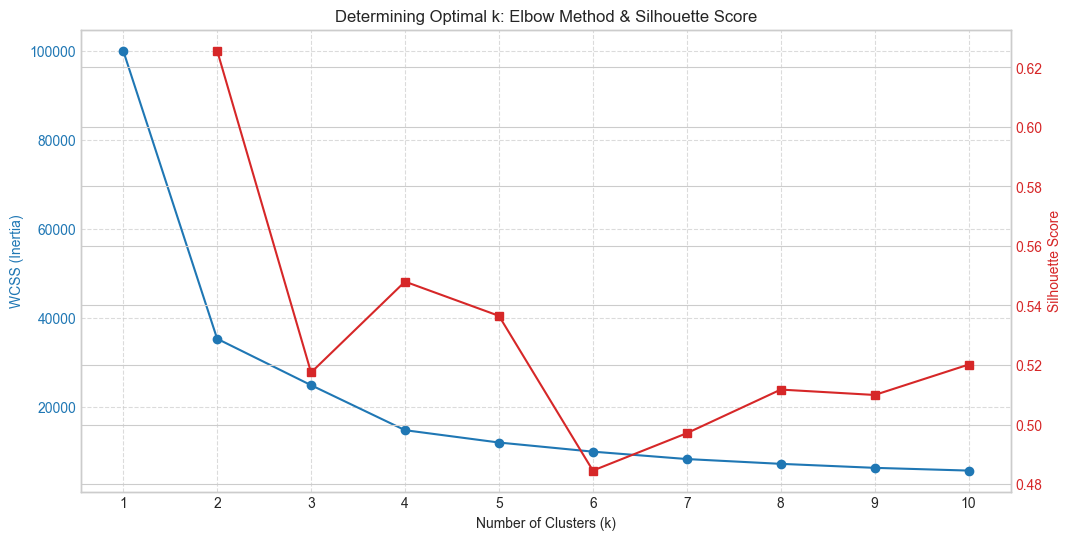

In [21]:
# Initialize lists to store parameters
wcss = [] 
silhouette_avg = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # WCSS (Elbow Method) 
    wcss.append(kmeans.inertia_)
    
    # Silhouette Score 
    if k > 1: # Silhoutte Score only exists where k > 1
        score = silhouette_score(X_scaled, cluster_labels)
        silhouette_avg.append(score)
    else:
        silhouette_avg.append(None) # Placeholder for k=1

# Visualization Purpose
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot WCSS (Left Axis)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='tab:blue')
ax1.plot(k_range, wcss, marker='o', linestyle='-', color='tab:blue', label='WCSS')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot Silhouette Score (Right Axis)
ax2 = ax1.twinx() 
ax2.set_ylabel('Silhouette Score', color='tab:red')

# Start the plot from index 1 (k=2) to skip the None value
ax2.plot(list(k_range)[1:], silhouette_avg[1:], marker='s', linestyle='-', color='tab:red', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Determining Optimal k: Elbow Method & Silhouette Score')
ax1.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_range)
plt.show()

In [22]:
# K-means clustering with the chosen k = 4
kmeans = KMeans(n_clusters= 4, random_state=42)
df['DRG_Proxy_Cluster'] = kmeans.fit_predict(X_scaled)

# Summary with cluster_features and median values for claim_amount and length_of_stay
cluster_summary = df.groupby('DRG_Proxy_Cluster')[cluster_features + ['total_claim_amount'] + ['length_of_stay']].median()
print("=== Cluster Center ===")
print(cluster_summary)

# Major category and procedure_diagnosis distribution in each cluster
print("\n=== Major Category in Each Cluster ===")
top_major = df.groupby('DRG_Proxy_Cluster')['major_category'].value_counts().groupby(level=0).head(3)
print(top_major)

print("\n" + "="*50 + "\n")

# Top 3 procedure diagnosis in each cluster
print("=== Top 3 Procedure Diagnoses in Each Cluster ===")
# Group by cluster and count the occurrences of each procedure diagnosis
top_diagnosis = df.groupby('DRG_Proxy_Cluster')['procedure_diagnosis'].value_counts().groupby(level=0).head(3)
print(top_diagnosis)

=== Cluster Center ===
                   chronic_conditions  doctor_fees  hospital_charges  \
DRG_Proxy_Cluster                                                      
0                                 2.0     8239.430          17976.94   
1                                 2.0    39930.400          87120.87   
2                                 0.0     5288.090          11537.64   
3                                 1.0    24358.605          53146.05   

                   investigation_cost  medication_cost  total_claim_amount  \
DRG_Proxy_Cluster                                                            
0                            4494.230         6741.350            37451.95   
1                           21780.220        32670.330           181501.82   
2                            2884.415         4326.615            24036.76   
3                           13286.510        19929.765           110720.93   

                   length_of_stay  
DRG_Proxy_Cluster                  
0  

In [23]:
# K-means clustering with the chosen k = 5
kmeans = KMeans(n_clusters= 5, random_state=42)
df['DRG_Proxy_Cluster'] = kmeans.fit_predict(X_scaled)

# Clustering summary with median values for claim_amount and length_of_stay
cluster_summary = df.groupby('DRG_Proxy_Cluster')[cluster_features + ['total_claim_amount'] + ['length_of_stay']].median()
print("=== Cluster Center ===")
print(cluster_summary)

# Major category and procedure_diagnosis distribution in each cluster
print("=== Major Category in Each Cluster ===")
top_major = df.groupby('DRG_Proxy_Cluster')['major_category'].value_counts().groupby(level=0).head(3)
print(top_major)

# Top 3 procedure diagnosis in each cluster
print("\n=== Top 3 Procedure Diagnoses in Each Cluster ===")
# Group by cluster and count the occurrences of each procedure diagnosis
top_diagnosis = df.groupby('DRG_Proxy_Cluster')['procedure_diagnosis'].value_counts().groupby(level=0).head(3)
print(top_diagnosis)

=== Cluster Center ===
                   chronic_conditions  doctor_fees  hospital_charges  \
DRG_Proxy_Cluster                                                      
0                                 2.0     8218.140         17930.480   
1                                 1.0    31171.915         68011.445   
2                                 0.0     5274.830         11508.710   
3                                 0.0    20799.000         45379.630   
4                                 2.0    43973.025         95941.145   

                   investigation_cost  medication_cost  total_claim_amount  \
DRG_Proxy_Cluster                                                            
0                             4482.62          6723.93            37355.17   
1                            17002.86         25504.29           141690.51   
2                             2877.18          4315.77            23976.49   
3                            11344.91         17017.36            94540.90   
4   

Although both evalution metrics (Elbow Method and Silhoutte Score) suggested that four clusters would be optimal, the results indicate that using five clusters provides a more nuanced and meaningful segmentation. With only four clusters, all surgical cases will belong into a single cluster, which overlooks important distinctions, especially the patients' chronic conditions. In contrast, a five-cluster solution captures these variations more effectively, resulting in a more detailed and interpretable grouping.

In [24]:
# Reorder the cluster by ascending order of the median of total_claim_amount
cluster_order = df.groupby('DRG_Proxy_Cluster')['total_claim_amount'].median().sort_values().index

mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_order)}

df['Ordered_DRG_Group'] = df['DRG_Proxy_Cluster'].map(mapping)
df_processed['Ordered_DRG_Group'] = df['Ordered_DRG_Group']

print(df.groupby('Ordered_DRG_Group')['total_claim_amount'].median())

print("\n=== Top 3 Procedure Diagnoses in Each Cluster ===")
top_diagnosis = df.groupby('Ordered_DRG_Group')['procedure_diagnosis'].value_counts().groupby(level=0).head(3)
print(top_diagnosis)

Ordered_DRG_Group
0     23976.49
1     37355.17
2     94540.90
3    141690.51
4    199877.39
Name: total_claim_amount, dtype: float64

=== Top 3 Procedure Diagnoses in Each Cluster ===
Ordered_DRG_Group  procedure_diagnosis      
0                  Dengue Haemorrhagic Fever    1669
                   Dengue Fever                 1645
                   COPD Exacerbation            1158
1                  Bronchitis                    429
                   Asthma Exacerbation           427
                   Pneumonia                     427
2                  Hip Replacement               481
                   Knee Replacement              451
                   Arthroscopy                   446
3                  Heart Valve Replacement       492
                   CABG                          457
                   Angioplasty with Stent        456
4                  CABG                          403
                   Heart Valve Replacement       373
                   Angioplas

### **Total Claim Cost Prediction Model**
With our DRGs established, we transitioned to predictive analytics to determine the "Fair Value" of every claim.
- We developed a Random Forest Regressor to forecast expected claim amounts. By training the model on historical indicators, such as `length_of_stay` and `procedure_diagnosis`, the model generates a "Fair Price" benchmark for any given claim.
- This model identifies claims where the submitted `total_claim_amount` deviates significantly from the predicted "Fair Price", serving as an automated sentinel. This allows insurers to flag high-cost outliers proactively, and promote insurance plans that suits their needs.

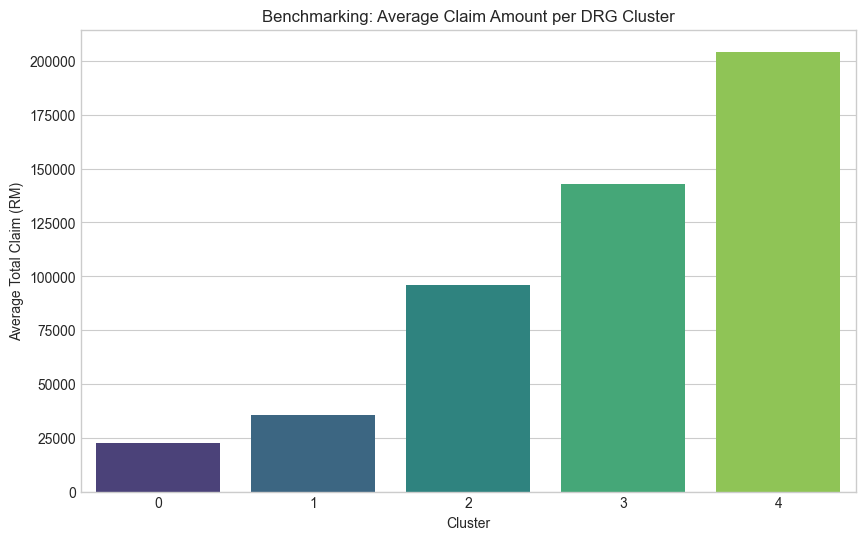

   Cluster      Avg_Claim  Median_Claim  Std_Dev_Claim  Max_Claim   Avg_LOS  \
0        0   22620.129164      23976.49   11019.262867   58831.90  4.255362   
1        1   35769.976449      37355.17   16782.116457  102104.07  6.425271   
2        2   95855.658451      94540.90   16807.592396  132759.73  5.011036   
3        3  142737.055335     141690.51   18982.073172  195865.72  6.899914   
4        4  204313.307979     199877.39   24869.721618  250000.00  8.628247   

   Median_LOS  Claim_Count  
0         4.0        10491  
1         6.0         3593  
2         5.0         2356  
3         7.0         2328  
4         9.0         1232  


In [25]:
# Calculate Benchmarks per DRG Cluster
drg_benchmarks = df.groupby('Ordered_DRG_Group').agg({
    'total_claim_amount': ['mean', 'median', 'std', 'max'],
    'length_of_stay': ['mean', 'median'],
    'claim_id': 'count'
}).reset_index()

# Rename columns for clarity
drg_benchmarks.columns = ['Cluster', 'Avg_Claim', 'Median_Claim', 'Std_Dev_Claim', 'Max_Claim', 'Avg_LOS', 'Median_LOS', 'Claim_Count']

# 2. Visualize the Benchmarks
plt.figure(figsize=(10, 6))
sns.barplot(data=drg_benchmarks, x='Cluster', y='Avg_Claim', palette='viridis')
plt.title('Benchmarking: Average Claim Amount per DRG Cluster')
plt.ylabel('Average Total Claim (RM)')
plt.show()

print(drg_benchmarks)

In [26]:
# Feature preparation for individual prediction
# Using the Ordered_DRG_Group with the individual's profile
features_for_model = [
    'patient_age', 'bmi', 'chronic_conditions', 'length_of_stay', 
    'patient_gender', 'smoker_status', 'region', 'hospital_type', 'Ordered_DRG_Group'
]

# Create X (features) and y (target)
X = df_processed[features_for_model]
y = df_processed['total_claim_amount']

# To check the accuracy of the model by using R2 score, RMSE and MAE score
X_eval = X 
y_eval = df_processed['total_claim_amount']

X_train, X_test, y_train, y_test = train_test_split(X_eval, y_eval, test_size=0.2, random_state=42)

# Train the Random Forest Regressor Model
rf_regressor = RandomForestRegressor(n_estimators=200, random_state=42)
rf_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred_test = rf_regressor.predict(X_test)

# Calculate the metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("=== Random Forest Regressor ===")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Train on the whole set to establish the "standard" and then predict back onto it
rf_regressor.fit(X, y)

# Generate a unique "Supposed Amount" for every single row
df_processed['supposed_claim_amount'] = rf_regressor.predict(X)

# Calculate how much each specific person was over/undercharged
df_processed['variance_amount'] = df_processed['total_claim_amount'] - df_processed['supposed_claim_amount']
df_processed['variance_percentage'] = (df_processed['variance_amount'] / df_processed['supposed_claim_amount']) * 100

# Define an overcharge threshold (e.g., More than 15% above the predicted price)
df_processed['is_overcharged'] = df_processed['variance_percentage'] > 15

# Show specific entries that are problematic
overcharged_list = df_processed[df_processed['is_overcharged'] == True][
    ['procedure_diagnosis', 'total_claim_amount', 'supposed_claim_amount', 'variance_amount', 'variance_percentage']
].sort_values(by='variance_percentage', ascending=False)

print("\n=== Top 10 Specifically Overcharged Entries ===")
print(overcharged_list.head(10))


=== Random Forest Regressor ===
R-squared (R2): 0.9695
Mean Absolute Error (MAE): 6773.48
Root Mean Squared Error (RMSE): 9874.69

=== Top 10 Specifically Overcharged Entries ===
       procedure_diagnosis  total_claim_amount  supposed_claim_amount  \
1175                     1            25575.04           12648.096184   
15027                   10            22659.90           11600.558059   
13759                   10            36978.53           19403.460429   
16846                   14            26152.42           13738.533929   
1374                    14            24522.26           12894.563587   
3882                    10            27838.49           14839.971445   
11560                    9            33744.27           18573.800573   
17033                    5            46237.40           25535.316550   
18393                   10            22571.43           12514.246604   
2362                    11            28071.78           15686.568057   

       variance_a

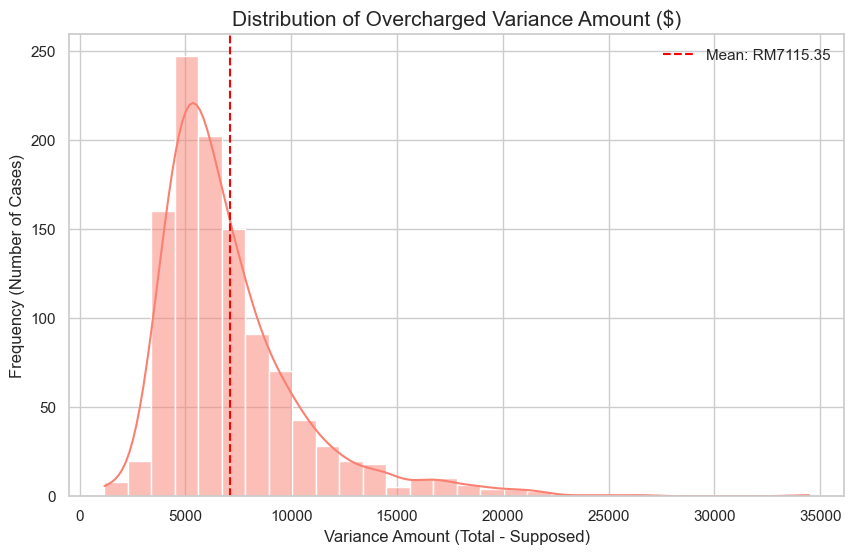

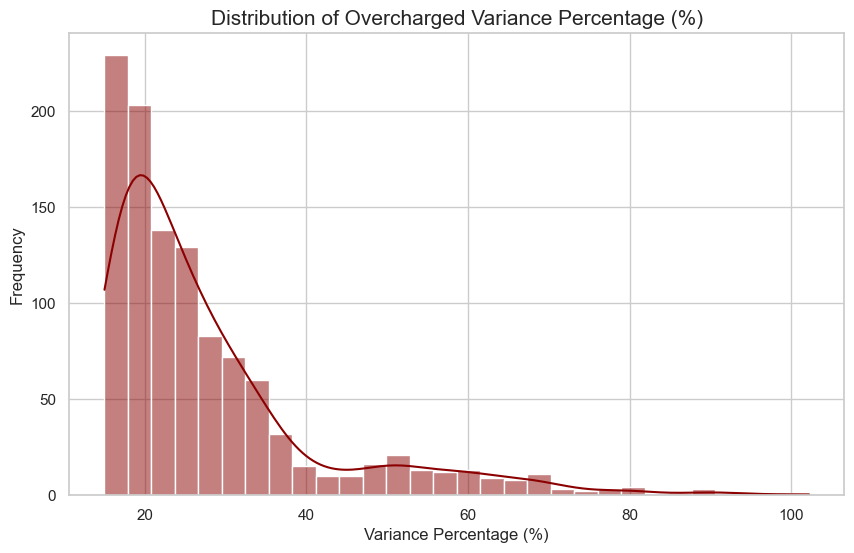

In [27]:
# Filter the data to only include overcharged entries
overcharged_data = df_processed[df_processed['is_overcharged'] == True]

sns.set_theme(style="whitegrid")

# Create the plot for variance amount
plt.figure(figsize=(10, 6))
sns.histplot(overcharged_data['variance_amount'], kde=True, color='salmon', bins=30)

plt.title('Distribution of Overcharged Variance Amount ($)', fontsize=15)
plt.xlabel('Variance Amount (Total - Supposed)', fontsize=12)
plt.ylabel('Frequency (Number of Cases)', fontsize=12)

# Add a vertical line for the average variance
plt.axvline(overcharged_data['variance_amount'].mean(), color='red', linestyle='--', label=f'Mean: RM{overcharged_data["variance_amount"].mean():.2f}')
plt.legend()

plt.show()

# Create a plot for variance percentage
plt.figure(figsize=(10, 6))
sns.histplot(overcharged_data['variance_percentage'], kde=True, color='darkred', bins=30)
plt.title('Distribution of Overcharged Variance Percentage (%)', fontsize=15)
plt.xlabel('Variance Percentage (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

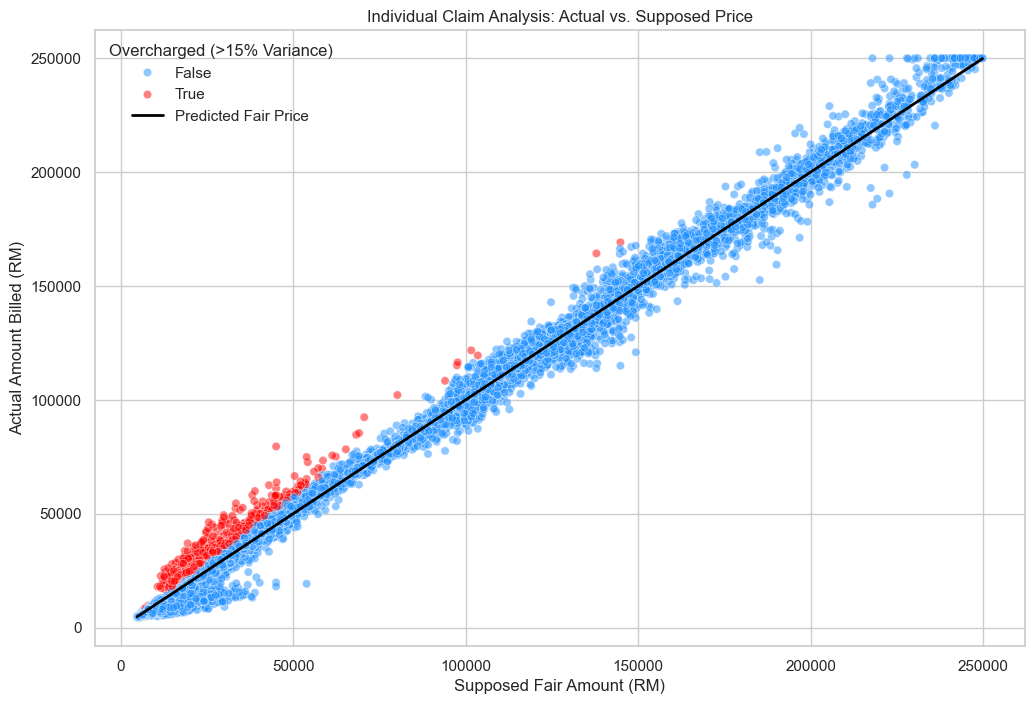

In [28]:
plt.figure(figsize=(12, 8))

# Scatter plot of every entry
sns.scatterplot(data=df_processed, x='supposed_claim_amount', y='total_claim_amount', 
                hue='is_overcharged', palette={True: 'red', False: 'dodgerblue'}, alpha=0.5)

# The Predicted Fair Price Line
line_coords = [df_processed['supposed_claim_amount'].min(), df_processed['supposed_claim_amount'].max()]
plt.plot(line_coords, line_coords, color='black', lw=2, label='Predicted Fair Price')

plt.title('Individual Claim Analysis: Actual vs. Supposed Price')
plt.xlabel('Supposed Fair Amount (RM)')
plt.ylabel('Actual Amount Billed (RM)')
plt.legend(title="Overcharged (>15% Variance)")
plt.show()

### **Hospital Tiering**
The final stage of our framework synthesizes the predictive deviations into a Risk-Severity Matrix, providing the Ministry of Health with a definitive roadmap for targeted auditing.
- We aggregated the frequency and magnitude of deviations (identified by our predictive model) to calculate a composite `risk_score` for every hospital. Then, we applied an upper-quartile threshold to segment the hospitals:
    * Tier 1 (Standard): Hospitals whose billing behaviors align with the predictive benchmark.
    * Tier 2 (High Risk): Hospitals whose performance metrics exceed the 75th percentile.
- This tiering model provides a defensible basis for regulatory action. It prioritises the "Tier 2" facilities for proactive clinical audits and value-based contract renegotiations, effectively operationalising the MHIT Plan's goal to strengthen healthcare sustainability through data-driven governance.

In [29]:
# Group by region to calculate the regional benchmark
region_stats = df_processed.groupby('region').agg({
    'total_claim_amount': ['mean', 'median'],
    'supposed_claim_amount': ['mean', 'median']
})

region_stats.columns = ['orig_mean', 'orig_median', 'pred_mean', 'pred_median']

region_stats['mean_ratio'] = region_stats['orig_mean'] / region_stats['pred_mean']
region_stats['median_ratio'] = region_stats['orig_median'] / region_stats['pred_median']

region_stats.index = label_encoders['region'].inverse_transform(region_stats.index)

print("Regional Price Ratios:")
print(region_stats[['mean_ratio', 'median_ratio']])

Regional Price Ratios:
               mean_ratio  median_ratio
Central          1.001230      1.030252
East Coast       0.999760      1.036997
East Malaysia    0.995621      1.021312
Northern         1.001300      1.044553
Southern         1.002776      1.029574


In [30]:
# Add a new variable "is_overcharged_regional" to calculate if the entries is considered overcharged in that corresponding region
df_processed['region_name'] = label_encoders['region'].inverse_transform(df_processed['region'])
df_processed['region_name'] = df_processed['region_name'].astype(str)

region_stats.index = region_stats.index.astype(str)

df_processed = df_processed.merge(region_stats[['mean_ratio']], left_on='region_name', right_index=True, how='left')
df_processed['is_overcharged_regional'] = (df_processed['total_claim_amount'] / df_processed['supposed_claim_amount']) > df_processed['mean_ratio']

# Calculate the percentage of overcharge cases over total cases
overcharged_stats = df_processed.groupby('region_name')['is_overcharged_regional'].agg(['sum', 'count']).rename(
    columns={'sum': 'overcharged_count', 'count': 'total_cases'}

)
overcharged_stats['overcharged_percentage'] = (overcharged_stats['overcharged_count'] / overcharged_stats['total_cases']) * 100

print("=== Overcharged Cases by Region ===")
print(overcharged_stats)

=== Overcharged Cases by Region ===
               overcharged_count  total_cases  overcharged_percentage
region_name                                                          
Central                     1741         3541               49.166902
East Coast                  1867         3840               48.619792
East Malaysia               1814         3771               48.103951
Northern                    2479         5075               48.847291
Southern                    1803         3773               47.786907


In [ ]:
# Filter private hospitals only for tiering process
private_hospitals = df_processed[df_processed['hospital_type'] == 1].copy()

# Calculate the ratio of overcharged entry
private_hospitals['overcharge_ratio'] = private_hospitals['total_claim_amount'] / private_hospitals['supposed_claim_amount']

# Since the Risk-Severity Matrix is being used, the frequency and magnitude of overcharged entries are being calcultated
hospital_stats = private_hospitals.groupby('hospital_name').agg(
    overcharge_frequency=('is_overcharged_regional', 'mean'),
    median_magnitude=('overcharge_ratio', 'median')
)

# Normalize both data as they might have different ranges 
hospital_stats['norm_freq'] = (hospital_stats['overcharge_frequency'] - hospital_stats['overcharge_frequency'].min()) / \
                              (hospital_stats['overcharge_frequency'].max() - hospital_stats['overcharge_frequency'].min() + 1e-9)

hospital_stats['norm_mag'] = (hospital_stats['median_magnitude'] - hospital_stats['median_magnitude'].min()) / \
                             (hospital_stats['median_magnitude'].max() - hospital_stats['median_magnitude'].min() + 1e-9)

# Calculate the risk_score, with the frequency and magnitude having the same weightage
hospital_stats['risk_score'] = (hospital_stats['norm_freq'] * 0.5) + (hospital_stats['norm_mag'] * 0.5)

# Flag hospital with risk_score higher then 75% as Tier 2 hospital, otherwise labeled as Tier 1
tier_threshold = hospital_stats['risk_score'].quantile(0.75)
hospital_stats['hospital_tier'] = np.where(hospital_stats['risk_score'] <= tier_threshold, 'Tier 1', 'Tier 2')

hospital_stats.index = label_encoders['hospital_name'].inverse_transform(hospital_stats.index)

print("--- Tiered Private Hospitals (Risk-Severity Matrix) ---")
print(hospital_stats[['hospital_tier', 'overcharge_frequency', 'median_magnitude', 'risk_score']].sort_values(by='risk_score', ascending=False))

--- Tiered Private Hospitals (Risk-Severity Matrix) ---
                                  hospital_tier  overcharge_frequency  \
Borneo Medical Centre                    Tier 2              0.587500   
KPJ Kuching                              Tier 2              0.573964   
KPJ Penang                               Tier 2              0.545455   
Gleneagles Penang                        Tier 2              0.530466   
Subang Jaya Medical Centre               Tier 2              0.534884   
Mahkota Medical Centre                   Tier 2              0.517280   
Gleneagles KL                            Tier 2              0.524194   
Putra Medical Centre                     Tier 2              0.519417   
KPJ Perdana                              Tier 2              0.525761   
KPJ Selangor                             Tier 1              0.516129   
KPJ KL                                   Tier 1              0.514599   
Prince Court Medical Centre              Tier 1              0.51574

Please refer to the report for "Suggestions and Recommendations" part.